In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = ["#4C72B0", "#DD8452"]
print("Libraries loaded ✅")

Libraries loaded ✅


In [128]:
df = pd.read_csv("NoWaterBody.csv")
print("Shape:", df.shape)
df.head()

Shape: (4075, 14)


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
1,12.523841,93.105329,221.571312,36.006300,39.380945,2973.137417,6.969483,7433.062836,Agricultural,Loam,5377.538809,0,0,1
2,33.119108,86.672170,34.964006,27.209131,56.457308,3157.919948,4.864941,6681.891487,Agricultural,Clay,3994.453680,0,1,1
3,8.596950,93.696145,124.343018,28.064283,92.583714,4899.577894,7.810204,4678.600389,Urban,Clay,8532.878669,1,0,1
4,36.127386,89.141979,9.858818,41.868814,64.251178,2162.153214,1.406386,6384.522186,Urban,Peat,8509.318152,1,1,1


In [129]:
print("Data Types:\n")
print(df.dtypes)
print("\nNull values:\n")
print(df.isnull().sum())

Data Types:

Latitude                  float64
Longitude                 float64
Rainfall (mm)             float64
Temperature (°C)          float64
Humidity (%)              float64
River Discharge (m³/s)    float64
Water Level (m)           float64
Elevation (m)             float64
Land Cover                 object
Soil Type                  object
Population Density        float64
Infrastructure              int64
Historical Floods           int64
Flood Occurred              int64
dtype: object

Null values:

Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64


In [130]:
print("Target distribution:")
print(df["Historical Floods"].value_counts())
df.describe()

Target distribution:
Historical Floods
1    2068
0    2007
Name: count, dtype: int64


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Flood Occurred
count,4075.000000,4075.000000,4075.000000,4075.000000,4075.000000,4075.000000,4075.000000,4075.000000,4075.000000,4075.00000,4075.000000,4075.0
mean,22.228718,82.493842,150.616610,29.833604,60.497406,2495.245461,4.958275,4382.731102,5005.065906,0.49865,0.507485,1.0
std,8.336635,8.418679,86.276484,8.647765,23.081223,1461.237713,2.902505,2533.854004,2882.451569,0.50006,0.500005,0.0
min,8.000891,68.024757,0.033070,15.017843,20.001339,1.616158,0.002701,1.150340,5.051718,0.00000,0.000000,1.0
25%,15.060411,75.197968,76.082222,22.236303,40.538107,1211.246074,2.420238,2183.641782,2448.329145,0.00000,0.000000,1.0
50%,22.199678,82.569557,151.265960,29.711126,60.483388,2486.218098,4.931606,4350.189438,5074.208209,0.00000,1.000000,1.0
75%,29.319344,89.820030,224.690534,37.164632,80.896351,3778.724426,7.525388,6579.638018,7483.579860,1.00000,1.000000,1.0
max,36.985651,96.990523,299.970293,44.993681,99.996556,4998.844824,9.996899,8846.894877,9999.169530,1.00000,1.000000,1.0


In [131]:
TARGET = "Historical Floods"
DROP_COLS = ["Flood Occurred"]   # all-1, no variance

le_lc = LabelEncoder()
le_st = LabelEncoder()
df["Land Cover"] = le_lc.fit_transform(df["Land Cover"])
df["Soil Type"]  = le_st.fit_transform(df["Soil Type"])

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

feature_names = X.columns.tolist()
print("Features:", feature_names)
print("Target classes:", y.unique())

Features: ['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure']
Target classes: [1 0]


In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (3260, 12) | Test: (815, 12)


In [133]:
model = DecisionTreeClassifier(
    criterion="gini",   
    max_depth=4,           
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [134]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)

y_pred  = dt.predict(X_test)
y_prob  = dt.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))

Test Accuracy: 0.4601

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.45      0.46      0.46       401
       Flood       0.47      0.46      0.46       414

    accuracy                           0.46       815
   macro avg       0.46      0.46      0.46       815
weighted avg       0.46      0.46      0.46       815



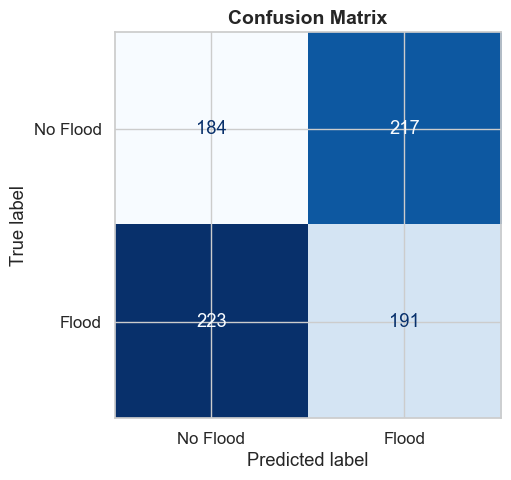

In [135]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flood", "Flood"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

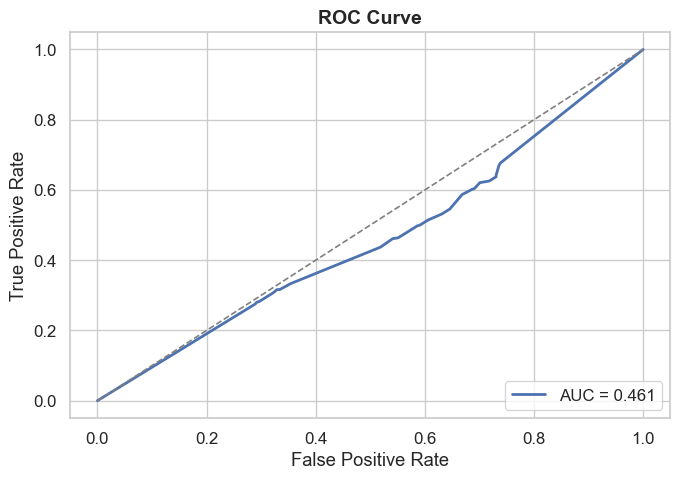

In [136]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1.2)
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_12008\435274427.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", palette="Blues_r", ax=ax)


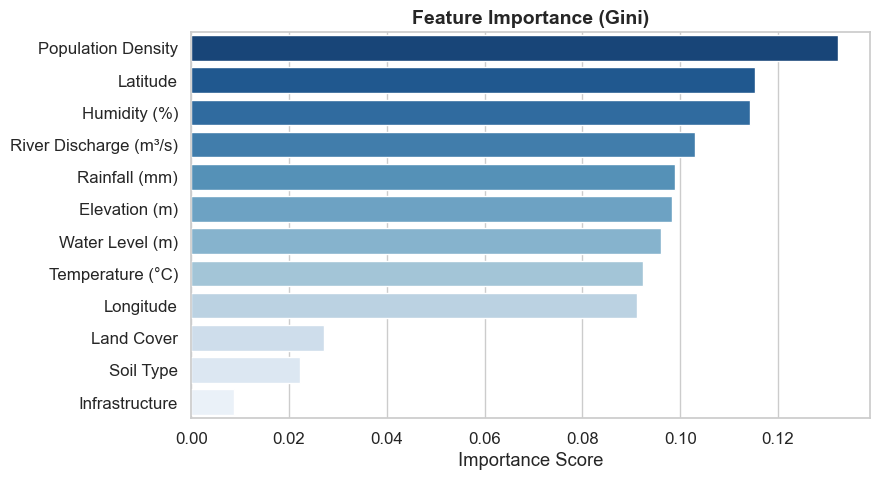

In [137]:
# ── Feature Importance ────────────────────────────────────────────────────────
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": dt.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=imp_df, x="importance", y="feature", palette="Blues_r", ax=ax)
ax.set_title("Feature Importance (Gini)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

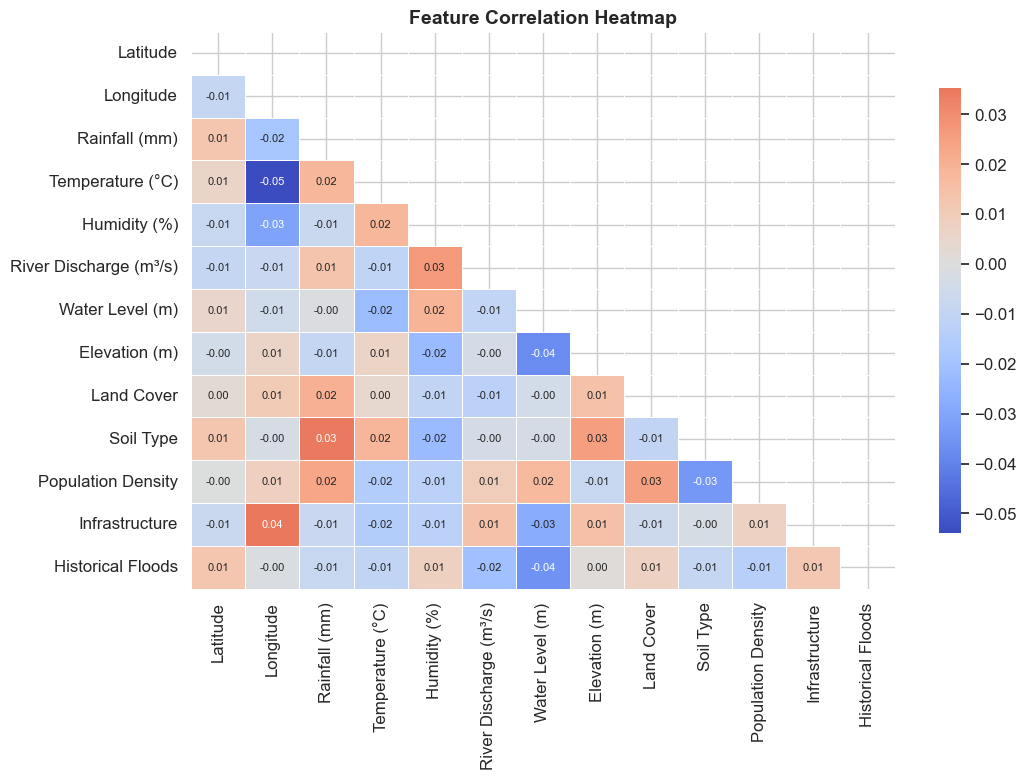

In [138]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
numeric_df = df[feature_names + [TARGET]].select_dtypes(include="number")
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.4, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

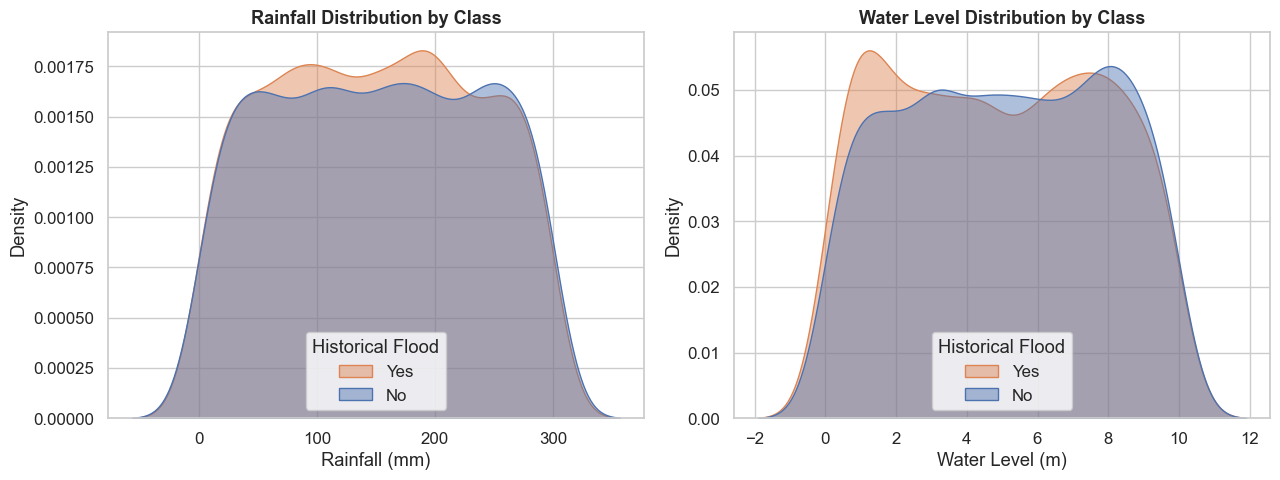

In [139]:
# ── Rainfall & Water Level distributions by class ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.kdeplot(data=df, x="Rainfall (mm)", hue=TARGET,
            palette=PALETTE, fill=True, alpha=0.45, ax=axes[0])
axes[0].set_title("Rainfall Distribution by Class", fontsize=13, fontweight="bold")
axes[0].legend(title="Historical Flood", labels=["Yes", "No"])

sns.kdeplot(data=df, x="Water Level (m)", hue=TARGET,
            palette=PALETTE, fill=True, alpha=0.45, ax=axes[1])
axes[1].set_title("Water Level Distribution by Class", fontsize=13, fontweight="bold")
axes[1].legend(title="Historical Flood", labels=["Yes", "No"])

plt.tight_layout()
plt.show()

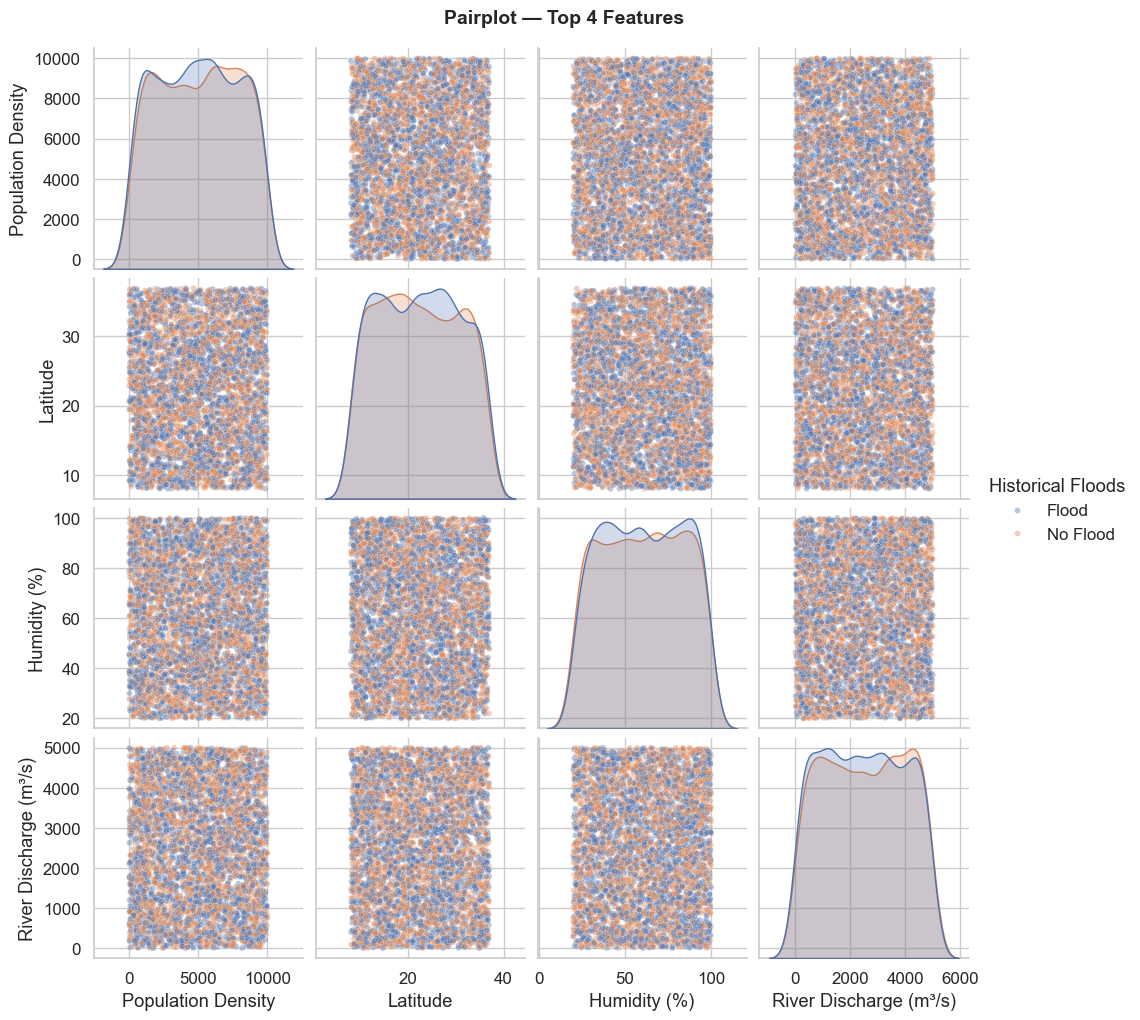

In [140]:
# ── Pairplot (top 4 features) ─────────────────────────────────────────────────
top4 = imp_df["feature"].head(4).tolist()
pair_df = df[top4 + [TARGET]].copy()
pair_df[TARGET] = pair_df[TARGET].map({0: "No Flood", 1: "Flood"})

g = sns.pairplot(pair_df, hue=TARGET, palette=PALETTE,
                 plot_kws={"alpha": 0.4, "s": 18},
                 diag_kind="kde")
g.figure.suptitle("Pairplot — Top 4 Features", y=1.02, fontsize=14, fontweight="bold")
plt.show()

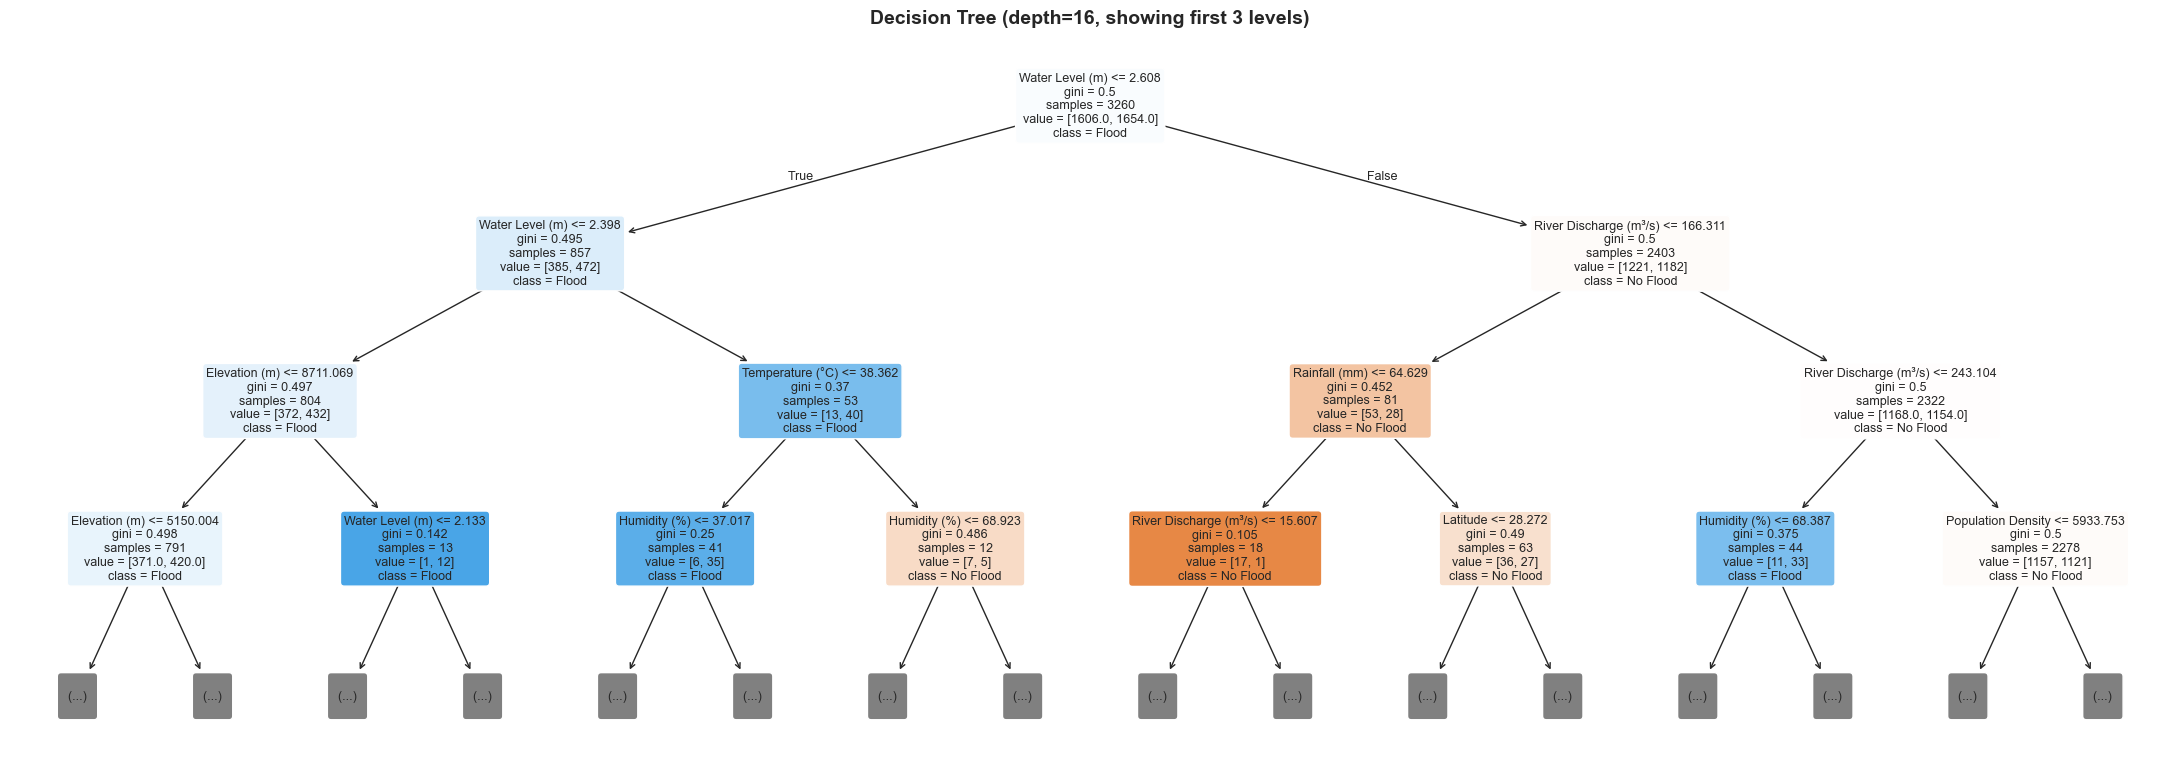

In [141]:
# ── Decision Tree (first 3 levels) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=3, feature_names=feature_names,
          class_names=["No Flood", "Flood"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f"Decision Tree (depth={best_depth}, showing first 3 levels)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [142]:
print("=" * 45)
print("       DECISION TREE MODEL SUMMARY")
print("=" * 45)
print(f"  Best max_depth  : {best_depth}")
print(f"  CV Accuracy     : {max(cv_scores):.4f}")
print(f"  Test Accuracy   : {test_acc:.4f}")
print(f"  ROC AUC         : {roc_auc:.4f}")
print(f"  Top feature     : {imp_df.iloc[0]['feature']}")
print("=" * 45)

       DECISION TREE MODEL SUMMARY
  Best max_depth  : 16
  CV Accuracy     : 0.5175
  Test Accuracy   : 0.4601
  ROC AUC         : 0.4611
  Top feature     : Population Density
